-------------------------------
### Classification - using mnist data

- Loads the MNIST dataset.
- Preprocesses the images and labels (normalizing the images to [0, 1] and one-hot encoding the labels).
- Defines a simple MLP model with two hidden layers.
- Compiles and trains the model.
- Evaluates the model on the test dataset.
- Plots the training and validation accuracy and loss over epochs.
-----------------

In [28]:
import numpy as np
np.set_printoptions(edgeitems=10, linewidth=160)
import matplotlib.pyplot as plt

from keras.datasets import mnist

from keras.models import Sequential
from keras.layers import Dense, Flatten

from keras.utils import to_categorical, plot_model

In [29]:
# Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [30]:
train_images.shape, test_images.shape

((60000, 28, 28), (10000, 28, 28))

In [31]:
train_images[30]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0

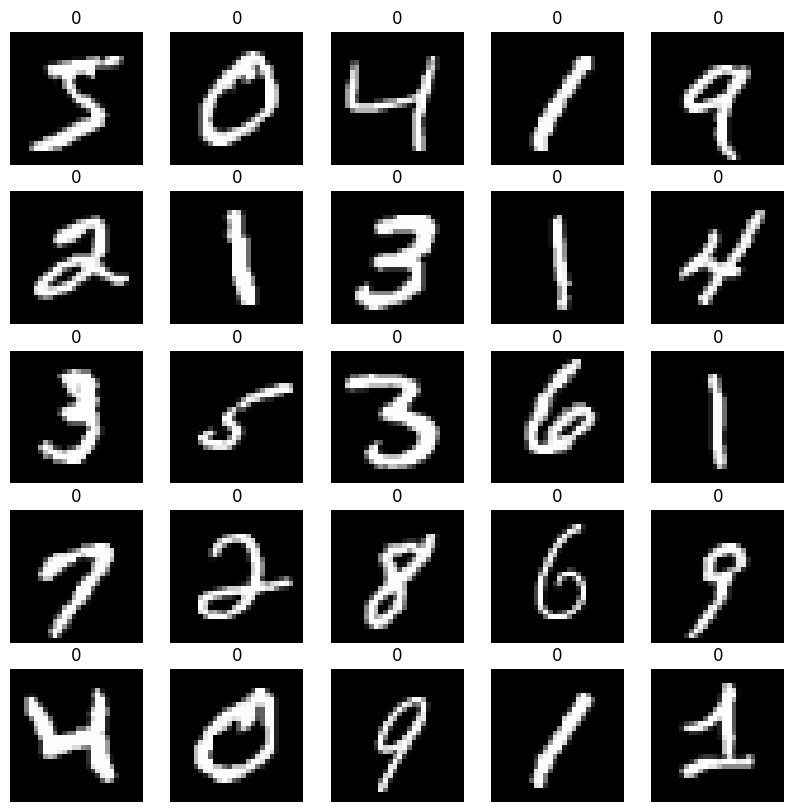

In [32]:
# Plot some samples from MNIST
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(str(np.argmax(train_labels[i])))
    plt.axis('off')

In [33]:
# Preprocess the data
# Scaling the data  x-min / (max-min)  =>  x/255
train_images = train_images.astype('float32') / 255.0
test_images  =  test_images.astype('float32') / 255.0

In [34]:
train_images.shape

(60000, 28, 28)

In [35]:
 train_labels

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, ..., 9, 2, 9, 5, 1, 8, 3, 5, 6, 8], shape=(60000,), dtype=uint8)

In [36]:
np.set_printoptions(edgeitems=10)

In [37]:
to_categorical(train_labels)

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]], shape=(

In [38]:
# One-hot encode the labels
# There will be 1 in the index of the class and rest all will be 0
train_labels = to_categorical(train_labels)
test_labels  = to_categorical(test_labels)

In [39]:
# Define the MLP model
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))  # Flatten the 28x28 images

model.add(Dense(512, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(10,  activation='softmax'))  # 10 output units for 10 digits (0-9)

In [40]:
# Compile the model 
model.compile(optimizer = 'sgd', 
              loss      = 'categorical_crossentropy', 
              metrics   = ['accuracy'])

In [41]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
# # Visualize the model architecture
# plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)
# plt.imshow(plt.imread('model_plot.png'))
# plt.axis('off')

In [44]:
# Train the model
history = model.fit(train_images, 
                    train_labels, 
                    epochs          = 10, 
                    batch_size      = 32, 
                    validation_split= 0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9722 - loss: 0.1007 - val_accuracy: 0.9683 - val_loss: 0.1171
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9749 - loss: 0.0926 - val_accuracy: 0.9689 - val_loss: 0.1117
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9771 - loss: 0.0854 - val_accuracy: 0.9688 - val_loss: 0.1076
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9787 - loss: 0.0796 - val_accuracy: 0.9693 - val_loss: 0.1065
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9801 - loss: 0.0735 - val_accuracy: 0.9703 - val_loss: 0.1039
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9819 - loss: 0.0686 - val_accuracy: 0.9710 - val_loss: 0.0987
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - accuracy: 0.9832 - loss: 0.0640 - val_accuracy: 0.9728 - val_loss: 0.0956
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9843 - loss: 0.

In [45]:
# Evaluate the model
test_labels = np.squeeze(test_labels)
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9748 - loss: 0.0827
Test accuracy: 0.9747999906539917


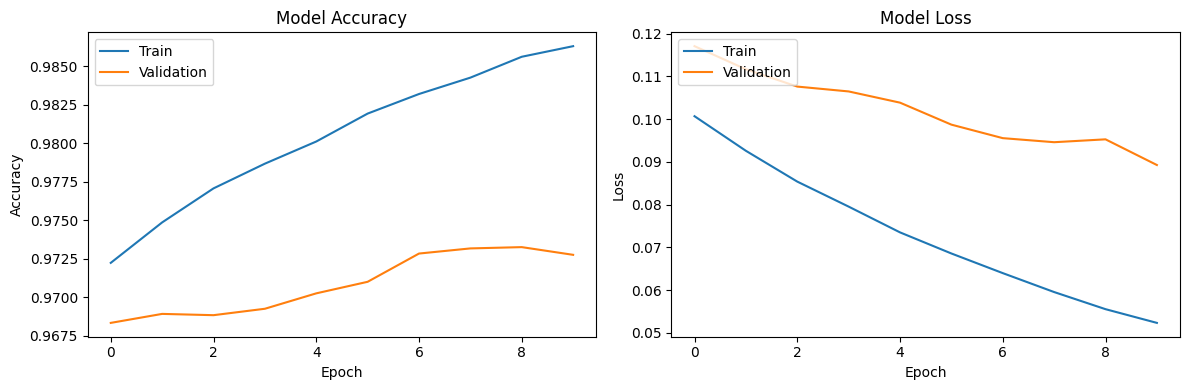

In [46]:
# Plot training & validation accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()